## Logistic Regression Baseline

### Purpose
Build a baseline logistic regression model restricted to the 15 features
selected by SHAP in `feature_importance.py`. This baseline is the direct
performance reference point for the Bayesian network models trained on the
same feature set.

### Overview
`data/bayesian_outputs/selected_features.json` stores raw feature names
(e.g. `device_os`), but the preprocessed parquets contain OHE-expanded
columns (e.g. `device_os_macintosh`). This notebook bridges that mismatch
by expanding the 4 categorical selected features to their OHE columns before
training, yielding ~26 model columns from 15 logical features.
`class_weight="balanced"` is used throughout to handle the ~1.1% fraud rate.

### Sections
| # | Section | Description |
|---|------|-------------|
| 0 | Load config | Load selected features + OHE schema; expand to `lr_cols` |
| 0a | Column visibility | Print before/after OHE expansion for inspection |
| 1 | Load data | Read parquets, filter to `lr_cols`, report class balance |
| 2 | Train model | Fit `LogisticRegression(class_weight="balanced")` |
| 3 | Evaluate | Confusion matrix, classification report, ROC/PR AUC, MCC |
| 4 | ROC & PR curves | Side-by-side threshold-independent performance plots |
| 5 | Feature importances | Aggregate \|coef\| to base feature names; bar chart |

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    roc_auc_score,
)

In [2]:
# 0. Load config and expand selected features to OHE columns
with open("../data/bayesian_outputs/selected_features.json") as f:
    selected_features = json.load(f)["top_features"]

with open("../data/preprocessed/features.json") as f:
    features = json.load(f)

ohe_all = features["ohe"]  # all OHE columns present in parquet
cat_names = features["categorical"]  # base categorical names (device_os, etc.)

# For each selected feature: expand to its OHE columns if categorical, else use directly
direct_cols = [f for f in selected_features if f not in cat_names]
ohe_cols = [
    col
    for f in selected_features
    if f in cat_names
    for col in ohe_all
    if col.startswith(f + "_")
]

lr_cols = direct_cols + ohe_cols
print(f"Selected features: {len(selected_features)}")
print(f"  Direct (numeric/binary): {len(direct_cols)}")
print(f"  Expanded OHE columns:    {len(ohe_cols)}")
print(f"  Total lr_cols:           {len(lr_cols)}")

Selected features: 15
  Direct (numeric/binary): 11
  Expanded OHE columns:    20
  Total lr_cols:           31


In [3]:
# 0a. Column visibility — before and after OHE expansion
print("Before expansion (raw selected features):")
for f in selected_features:
    print(f"  {f}")

print("\nAfter expansion (lr_cols passed to model):")
for col in lr_cols:
    prefix = next((f for f in selected_features if col.startswith(f + "_")), None)
    tag = f"  [{prefix}]" if prefix else ""
    print(f"  {col}{tag}")

Before expansion (raw selected features):
  device_os
  prev_address_months_count_is_missing
  housing_status
  phone_home_valid
  has_other_cards
  employment_status
  income
  keep_alive_session
  name_email_similarity
  credit_risk_score
  payment_type
  customer_age
  bank_months_count_is_missing
  email_is_free
  current_address_months_count_is_missing

After expansion (lr_cols passed to model):
  prev_address_months_count_is_missing
  phone_home_valid
  has_other_cards
  income
  keep_alive_session
  name_email_similarity
  credit_risk_score
  customer_age
  bank_months_count_is_missing
  email_is_free
  current_address_months_count_is_missing
  device_os_macintosh  [device_os]
  device_os_other  [device_os]
  device_os_windows  [device_os]
  device_os_x11  [device_os]
  housing_status_BB  [housing_status]
  housing_status_BC  [housing_status]
  housing_status_BD  [housing_status]
  housing_status_BE  [housing_status]
  housing_status_BF  [housing_status]
  housing_status_BG  [ho

In [4]:
# 1. Load and filter data
train = pd.read_parquet("../data/preprocessed/train.parquet")
test = pd.read_parquet("../data/preprocessed/test.parquet")

X = train[lr_cols]
y = train["fraud_bool"]
X_test = test[lr_cols]
y_test = test["fraud_bool"]

fraud_rate = y.mean()
print(f"Train shape: {X.shape}  |  Fraud rate: {fraud_rate:.2%}")
print(f"Test shape:  {X_test.shape}")

Train shape: (800000, 31)  |  Fraud rate: 1.10%
Test shape:  (200000, 31)


In [5]:
# 2. Train baseline logistic regression
# class_weight="balanced" compensates for the ~1.1% fraud minority class
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X, y)
print("Model trained.")

Model trained.


[[158187  39607]
 [   425   1781]]
              precision    recall  f1-score   support

           0     0.9973    0.7998    0.8877    197794
           1     0.0430    0.8073    0.0817      2206

    accuracy                         0.7998    200000
   macro avg     0.5202    0.8035    0.4847    200000
weighted avg     0.9868    0.7998    0.8788    200000

ROC AUC: 0.8798
PR AUC:  0.1261
MCC:     0.1565


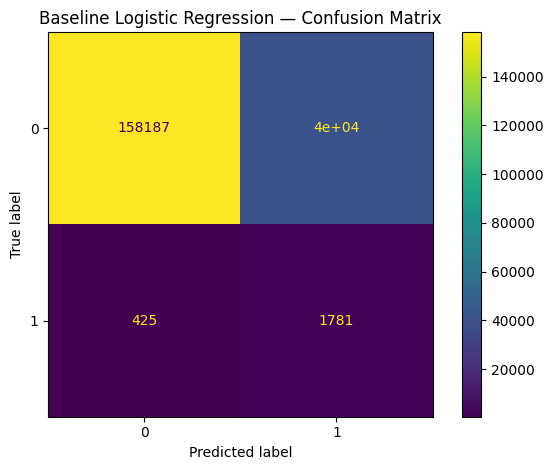

In [6]:
# 3. Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR AUC:  {average_precision_score(y_test, y_proba):.4f}")
print(f"MCC:     {matthews_corrcoef(y_test, y_pred):.4f}")

_, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title("Baseline Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

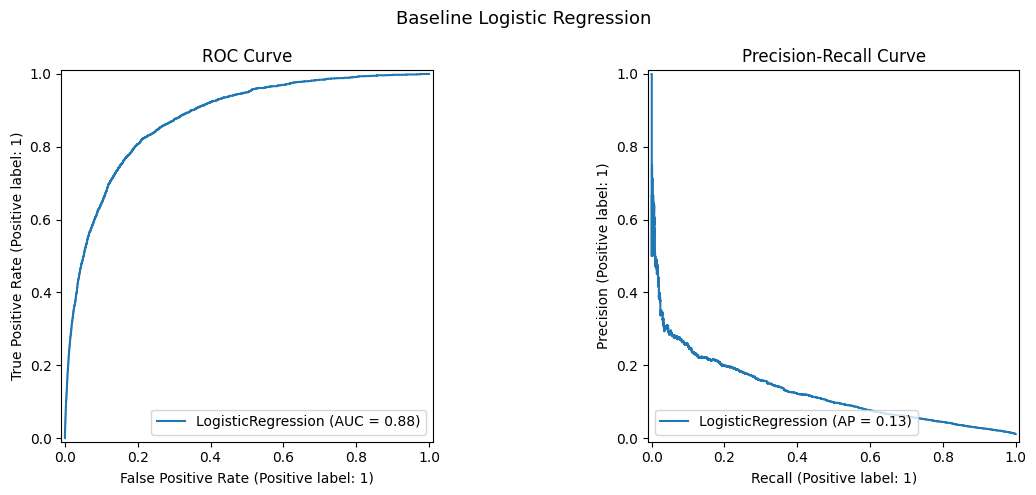

In [7]:
# 4. ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

fig.suptitle("Baseline Logistic Regression", fontsize=13)
plt.tight_layout()
plt.show()

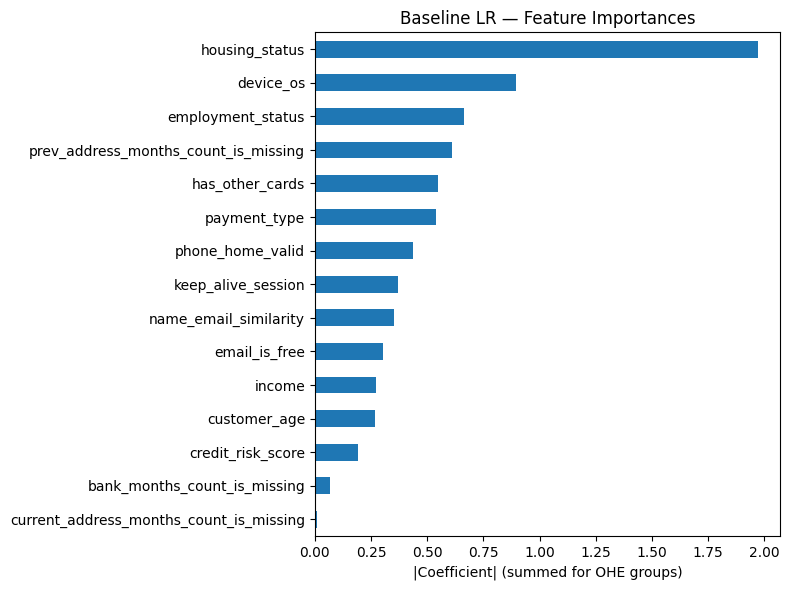

In [8]:
# 5. Feature importances by |coefficient|
# Aggregate OHE columns back to their original base feature name
coef_series = pd.Series(model.coef_[0], index=lr_cols)

grouped_coef = {}
for feat in selected_features:
    if feat in cat_names:
        cols = [c for c in ohe_cols if c.startswith(feat + "_")]
        grouped_coef[feat] = coef_series[cols].abs().sum()
    else:
        grouped_coef[feat] = abs(coef_series[feat])

importance = pd.Series(grouped_coef).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot.barh(ax=ax)
ax.set_xlabel("|Coefficient| (summed for OHE groups)")
ax.set_title("Baseline LR — Feature Importances")
plt.tight_layout()
plt.show()